 ### RQ3 - How do customer segments—such as first-time vs. repeat buyers or by region—differ in cancellation and return behavior, and can we predict these actions early based on browsing or shopping patterns to reduce churn?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                           roc_curve, precision_recall_curve, make_scorer, recall_score)
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryFocalCrossentropy
from scikeras.wrappers import KerasClassifier
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Data
data = pd.read_csv('/Users/alfonsoqu/Desktop/ASU/2025Summer/DAT 490/cleaned_dataset.csv')

In [3]:
print("Dataset Overview:")
print(f"Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
data.head()

Dataset Overview:
Shape: (111717, 41)
Columns: ['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_estimated_delivery_date', 'is_canceled', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'order_delivered_customer_date', 'is_first_time_buyer', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_lat', 'seller_lng', 'shipping_limit_date', 'order_delivered_carrier_date', 'handoff_delay', 'distance_km', 'product_id', 'product_category_name_english', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_id', 'review_score', 'delivered_late', 'delivery_delay']


,order_id,order_item_id,order_status,order_purchase_timestamp,order_approved_at,order_estimated_delivery_date,is_canceled,customer_id,customer_unique_id,customer_zip_code_prefix,...,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,delivered_late,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,delivered,2017-10-02,2017-10-02,2017-10-18,False,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,False,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,1.0,delivered,2018-07-24,2018-07-26,2018-08-13,False,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,8d5266042046a06655c8db133d120ba5,4.0,False,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,1.0,delivered,2018-08-08,2018-08-08,2018-09-04,False,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,False,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,1.0,delivered,2017-11-18,2017-11-18,2017-12-15,False,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,False,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,1.0,delivered,2018-02-13,2018-02-13,2018-02-26,False,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,e50934924e227544ba8246aeb3770dd4,5.0,False,-10.0


#### PART 1: CUSTOMER SEGMENTATION ANALYSIS

In [4]:
# Prepare data for segmentation
segmentation_data = data.copy()

# Create enhanced features for segmentation including regional analysis
segmentation_features = ['customer_state', 'is_first_time_buyer', 'price', 'freight_value',
                        'product_weight_g', 'distance_km', 'review_score', 'handoff_delay']

# Remove rows with missing values in key features
seg_data_clean = segmentation_data[segmentation_features + ['is_canceled']].dropna()

print(f"Data for segmentation: {seg_data_clean.shape}")

Data for segmentation: (109630, 9)


In [5]:
# Encode categorical variables for clustering
seg_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['customer_state']),
    ('num', StandardScaler(), ['price', 'freight_value', 'product_weight_g', 'distance_km',
                               'review_score', 'handoff_delay'])
])

In [6]:
# Create feature matrix for clustering (excluding is_first_time_buyer for now)
cluster_features = ['customer_state', 'price', 'freight_value', 'product_weight_g',
                   'distance_km', 'review_score', 'handoff_delay']
X_cluster = seg_preprocessor.fit_transform(seg_data_clean[cluster_features])

# Add is_first_time_buyer as binary feature
first_time_buyer = seg_data_clean['is_first_time_buyer'].astype(int).values.reshape(-1, 1)
X_cluster = np.hstack([X_cluster, first_time_buyer])

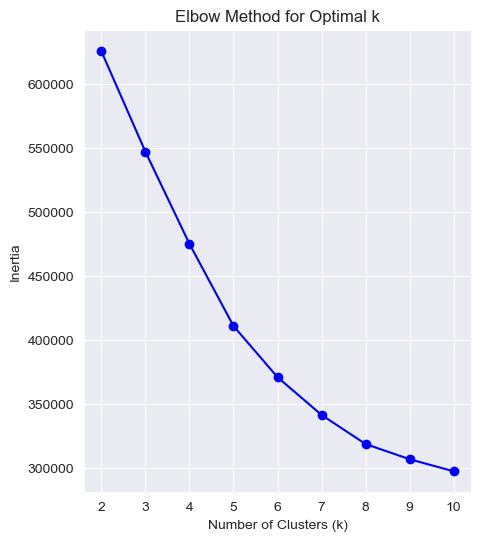

In [7]:
# Determine optimal number of clusters using elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(5, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [8]:
# Perform K-means clustering with optimal k (let's use k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Add cluster labels to the data
seg_data_clean['cluster'] = clusters

# Analyze cluster characteristics
print("\nCluster Analysis:")
cluster_analysis = seg_data_clean.groupby('cluster').agg({
    'is_canceled': ['count', 'mean'],
    'is_first_time_buyer': 'mean',
    'price': 'mean',
    'freight_value': 'mean',
    'product_weight_g': 'mean',
    'distance_km': 'mean',
    'review_score': 'mean',
    'handoff_delay': 'mean'
}).round(3)

print(cluster_analysis)


Cluster Analysis:
        is_canceled        is_first_time_buyer    price freight_value  \
              count   mean                mean     mean          mean   
cluster                                                                 
0             67118  0.000               0.786   87.900        15.091   
1              8785  0.001               0.795  323.093        43.161   
2             12566  0.001               0.801  119.318        29.929   
3             21161  0.002               0.622   86.753        15.894   

        product_weight_g distance_km review_score handoff_delay  
                    mean        mean         mean          mean  
cluster                                                          
0               1208.132     394.132        4.758        -3.622  
1              10547.196     588.419        4.064        -3.411  
2               1278.063    1879.624        4.102        -3.512  
3               1319.073     463.120        1.822        -2.793  


In [9]:
# Test 1: Cancellation rates across clusters
cluster_groups = [seg_data_clean[seg_data_clean['cluster'] == i]['is_canceled'] for i in range(optimal_k)]
f_stat, p_value = stats.f_oneway(*cluster_groups)
print(f"ANOVA test for cancellation rates across clusters:")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.8f}")

ANOVA test for cancellation rates across clusters:
F-statistic: 39.3967, p-value: 0.00000000


In [10]:
# Test 2: First-time vs repeat buyers cancellation rates
first_time_cancel = seg_data_clean[seg_data_clean['is_first_time_buyer'] == True]['is_canceled']
repeat_cancel = seg_data_clean[seg_data_clean['is_first_time_buyer'] == False]['is_canceled']
t_stat, p_value_ttest = stats.ttest_ind(first_time_cancel, repeat_cancel)
print(f"\nT-test for first-time vs repeat buyers:")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_value_ttest:.4f}")


T-test for first-time vs repeat buyers:
T-statistic: 2.6424, p-value: 0.0082


Text(0.5, 1.0, 'Cancellation Rates by Cluster')

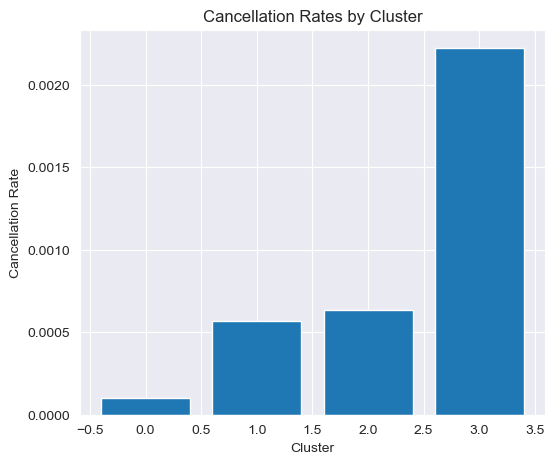

In [11]:
# Subplot 1: Cancellation rates by cluster
plt.figure(figsize=(6, 5))
cancel_rates = seg_data_clean.groupby('cluster')['is_canceled'].mean()
plt.bar(range(optimal_k), cancel_rates)
plt.xlabel('Cluster')
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rates by Cluster')

Text(0.5, 1.0, 'First-time Buyer Rate by Cluster')

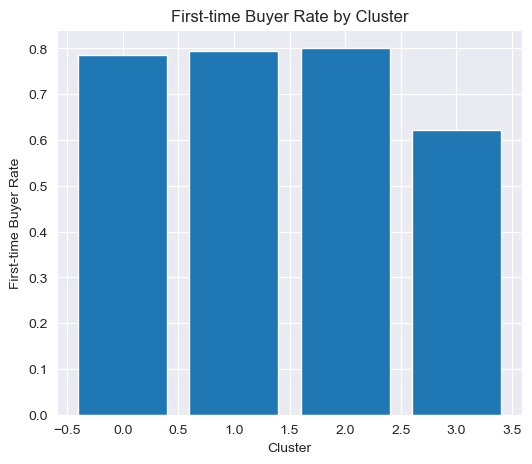

In [12]:
# Subplot 2: First-time buyer distribution by cluster
plt.figure(figsize=(6, 5))
first_time_rates = seg_data_clean.groupby('cluster')['is_first_time_buyer'].mean()
plt.bar(range(optimal_k), first_time_rates)
plt.xlabel('Cluster')
plt.ylabel('First-time Buyer Rate')
plt.title('First-time Buyer Rate by Cluster')

Text(0.5, 1.0, 'Average Price by Cluster')

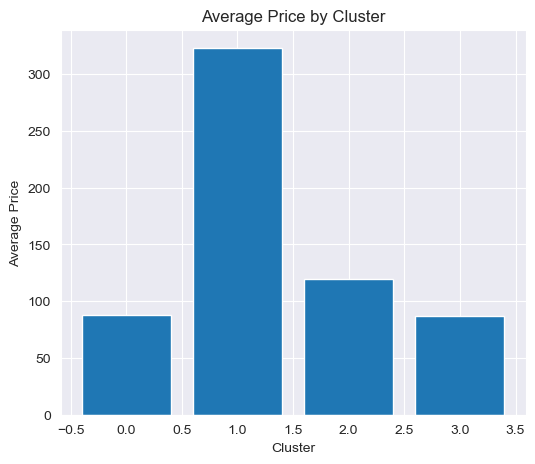

In [13]:
# Subplot 3: Average price by cluster
plt.figure(figsize=(6, 5))
avg_prices = seg_data_clean.groupby('cluster')['price'].mean()
plt.bar(range(optimal_k), avg_prices)
plt.xlabel('Cluster')
plt.ylabel('Average Price')
plt.title('Average Price by Cluster')

Text(0.5, 1.0, 'Cancellation Rate by Buyer Type')

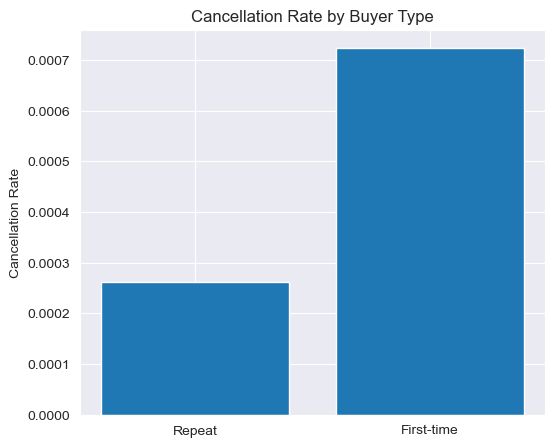

In [14]:
# Subplot 4: Cancellation by buyer type
plt.figure(figsize=(6, 5))
buyer_cancel = seg_data_clean.groupby('is_first_time_buyer')['is_canceled'].mean()
plt.bar(['Repeat', 'First-time'], buyer_cancel)
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by Buyer Type')

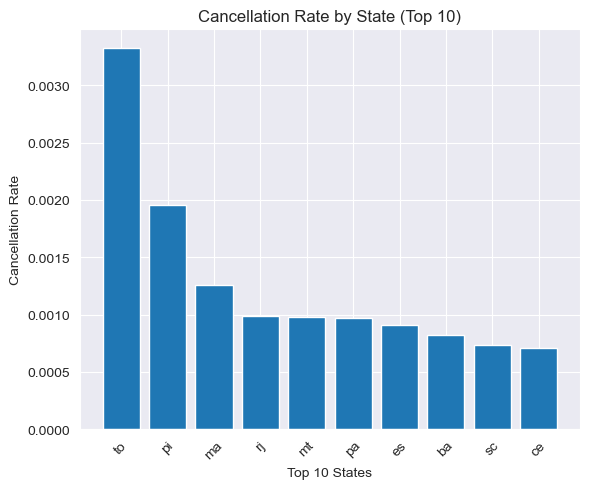

In [15]:
# Subplot 5: State-wise cancellation (top 10 states)
plt.figure(figsize=(6, 5))
state_cancel = seg_data_clean.groupby('customer_state')['is_canceled'].mean().sort_values(ascending=False).head(10)
plt.bar(range(len(state_cancel)), state_cancel.values)
plt.xlabel('Top 10 States')
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by State (Top 10)')
plt.xticks(range(len(state_cancel)), state_cancel.index, rotation=45)

plt.tight_layout()
plt.show()

#### PART 2: PREDICTIVE MODELING

In [16]:
# Data Preparation for Prediction
data_pred = data.copy()

# Remove unnecessary columns (keeping more features than the template for churn prediction)
columns_to_drop = ['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp',
                   'order_approved_at', 'order_estimated_delivery_date', 'customer_id',
                   'customer_unique_id', 'customer_zip_code_prefix', 'customer_lat',
                   'customer_lng', 'order_delivered_customer_date', 'seller_zip_code_prefix',
                   'seller_lat', 'seller_lng', 'shipping_limit_date', 'order_delivered_carrier_date',
                   'product_id', 'review_id']

data_pred.drop(columns=columns_to_drop, inplace=True)

print(f"Data shape after dropping unnecessary columns: {data_pred.shape}")
print(f"Remaining columns: {data_pred.columns.tolist()}")

# Check if is_first_time_buyer is still available
if 'is_first_time_buyer' in data_pred.columns:
    print("✓ is_first_time_buyer preserved for customer segmentation analysis")
else:
    print("✗ WARNING: is_first_time_buyer was removed - cannot distinguish first-time vs repeat customers")

# Remove NA rows
data_pred = data_pred.dropna()
print(f"Data shape after removing NA: {data_pred.shape}")

Data shape after dropping unnecessary columns: (111717, 22)
Remaining columns: ['is_canceled', 'customer_city', 'customer_state', 'is_first_time_buyer', 'seller_id', 'seller_city', 'seller_state', 'handoff_delay', 'distance_km', 'product_category_name_english', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_score', 'delivered_late', 'delivery_delay']
✓ is_first_time_buyer preserved for customer segmentation analysis
Data shape after removing NA: (106957, 22)


In [17]:
# Variable Selection
X = data_pred.drop(columns=['is_canceled'])
y = data_pred['is_canceled']

print(f"Target variable distribution:")
print(y.value_counts(normalize=True))

Target variable distribution:
is_canceled
False    0.999935
True     0.000065
Name: proportion, dtype: float64


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# Encoding Variables
categorical_features = ['customer_city', 'customer_state', 'seller_city', 'seller_state',
                       'seller_id', 'product_category_name_english']

numerical_features = ['handoff_delay', 'distance_km', 'price', 'freight_value',
                     'product_name_length', 'product_description_length', 'product_photos_qty',
                     'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
                     'review_score', 'delivery_delay']

# Add binary features
binary_features = ['is_first_time_buyer', 'delivered_late']

In [20]:
# Create preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features),
    ('num', StandardScaler(), numerical_features),
    ('bin', 'passthrough', binary_features)
])

# Transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Getting Feature Names
if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
    X_test_encoded = X_test_encoded.toarray()

# Get column names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(cat_feature_names) + numerical_features + binary_features

# Convert to DataFrames
X_train_df = pd.DataFrame(X_train_encoded, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_encoded, columns=all_feature_names)

print(f"Encoded feature matrix shape: {X_train_df.shape}")

Encoded feature matrix shape: (85565, 7219)


In [21]:
# Applying SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_df, y_train)

print(f"After SMOTE - X shape: {X_train_resampled.shape}")
print(f"After SMOTE - y distribution: {pd.Series(y_train_resampled).value_counts()}")

# Applying StratifiedKFold
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Focusing Recall for the Positive Cancellations
recall_scorer = make_scorer(recall_score, pos_label=True)

After SMOTE - X shape: (171118, 7219)
After SMOTE - y distribution: is_canceled
False    85559
True     85559
Name: count, dtype: int64


In [22]:
# Creating the Best Model
log_reg = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

grid_log_reg.fit(X_train_resampled, y_train_resampled)
best_log_reg = grid_log_reg.best_estimator_
print("Best Parameters:", grid_log_reg.best_params_)

# Testing the Model
y_proba_logreg = best_log_reg.predict_proba(X_test_df)[:, 1]

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .................................C=0.01, penalty=l1; total time=  23.0s
[CV] END .................................C=0.01, penalty=l1; total time=  24.5s
[CV] END .................................C=0.01, penalty=l1; total time=  23.9s
[CV] END .................................C=0.01, penalty=l1; total time=  24.2s
[CV] END .................................C=0.01, penalty=l1; total time=  24.0s
[CV] END .................................C=0.01, penalty=l2; total time=  23.1s
[CV] END .................................C=0.01, penalty=l2; total time=  24.2s
[CV] END .................................C=0.01, penalty=l2; total time=  24.1s
[CV] END .................................C=0.01, penalty=l2; total time=  24.7s
[CV] END .................................C=0.01, penalty=l2; total time=  24.2s
[CV] END ..................................C=0.1, penalty=l1; total time=  24.1s
[CV] END ..................................C=0.1,


Optimal Threshold (LogReg): 0.5944

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     21391
        True       0.02      1.00      0.04         1

    accuracy                           1.00     21392
   macro avg       0.51      1.00      0.52     21392
weighted avg       1.00      1.00      1.00     21392

ROC-AUC Score: 0.9977


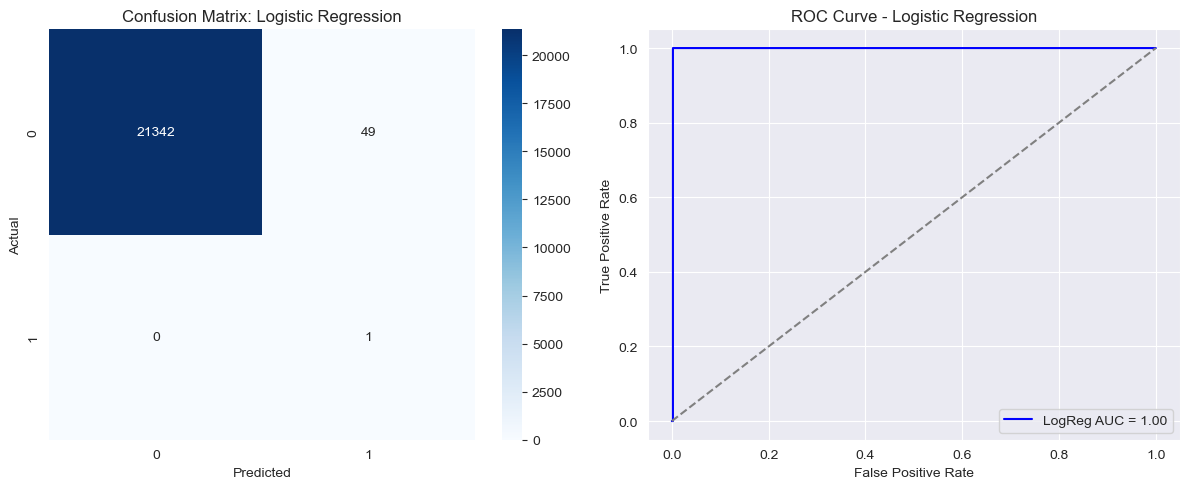

In [23]:
# Threshold Optimization
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_logreg)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-6)
optimal_threshold_logreg = thresholds[np.argmax(f2_scores)]
print(f"\nOptimal Threshold (LogReg): {optimal_threshold_logreg:.4f}")

y_pred_logreg_opt = (y_proba_logreg >= optimal_threshold_logreg).astype(int)

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logreg_opt))

roc_auc = roc_auc_score(y_test, y_proba_logreg)
print(f"ROC-AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_logreg_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
plt.plot(fpr, tpr, label=f"LogReg AUC = {roc_auc:.2f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

#### MODEL 2: RANDOM FOREST

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  28.1s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  28.7s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  28.4s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  28.5s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  29.7s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  41.6s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  42.4s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  41.6s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  4

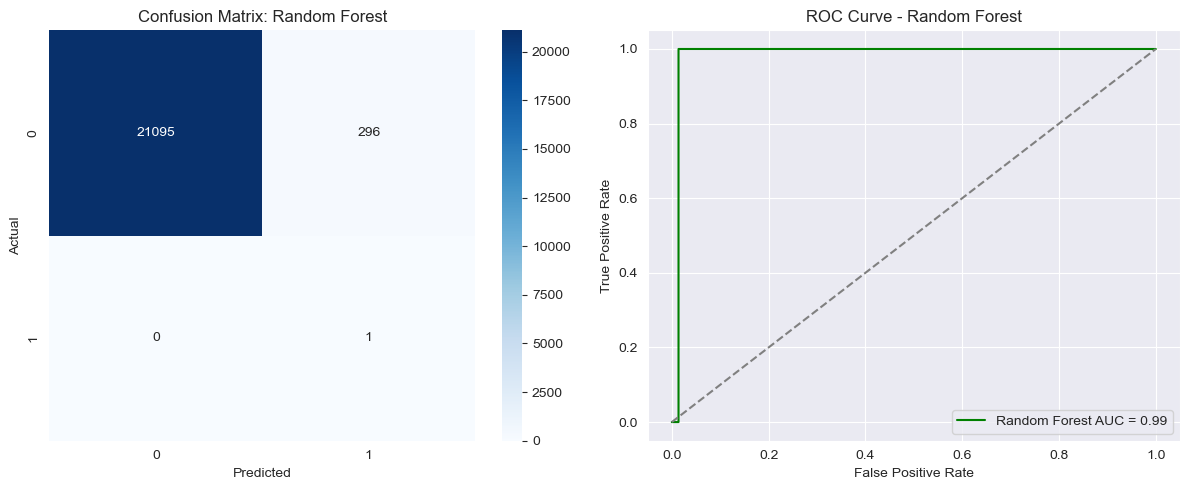

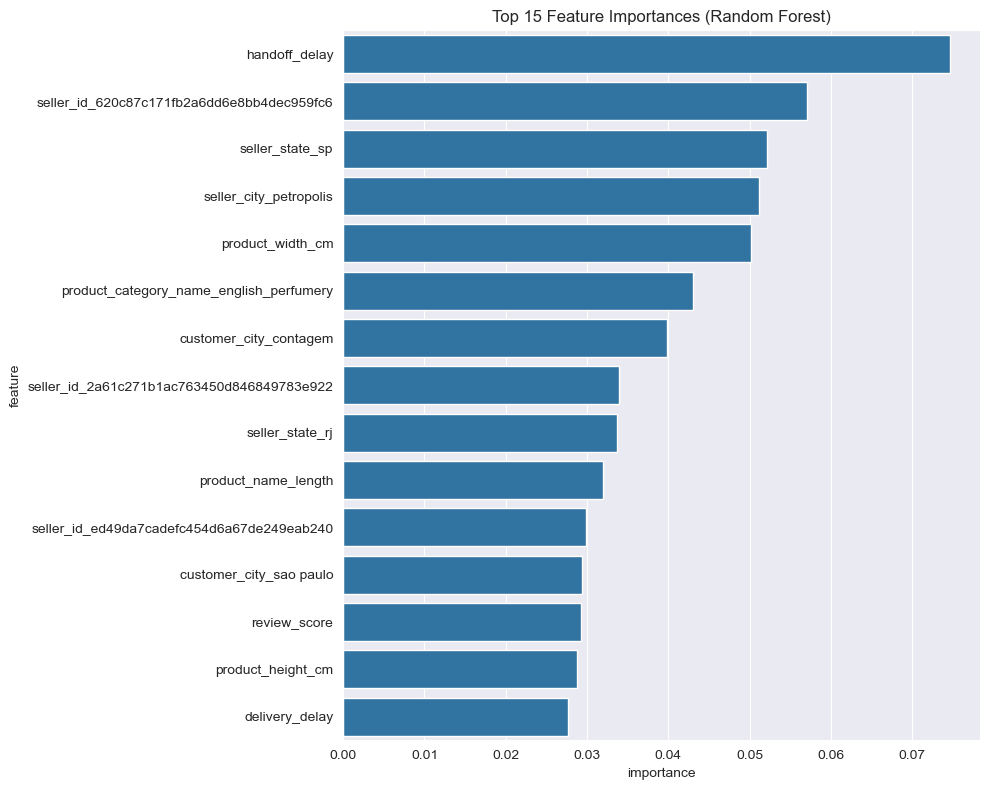

In [24]:
# Creating the Best Model
rf_clf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [10, 20],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_rf,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

grid_rf.fit(X_train_resampled, y_train_resampled)
best_rf = grid_rf.best_estimator_
print("Best Parameters (Random Forest):", grid_rf.best_params_)

# Evaluating the Model
y_proba_rf = best_rf.predict_proba(X_test_df)[:, 1]

precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)
f2_scores_rf = 5 * (precision_rf * recall_rf) / (4 * precision_rf + recall_rf + 1e-6)
optimal_threshold_rf = thresholds_rf[np.argmax(f2_scores_rf)]
print(f"\nOptimal Threshold (Random Forest): {optimal_threshold_rf:.4f}")

y_pred_rf_opt = (y_proba_rf >= optimal_threshold_rf).astype(int)

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf_opt))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, y='feature', x='importance')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

#### MODEL 3: ARTIFICIAL NEURAL NETWORK (ANN)

Epoch 1/15
5348/5348 - 20s - 4ms/step - Recall: 0.9975 - loss: 0.0027
Epoch 2/15
5348/5348 - 20s - 4ms/step - Recall: 0.9995 - loss: 6.3199e-04
Epoch 3/15
5348/5348 - 21s - 4ms/step - Recall: 0.9996 - loss: 3.7982e-04
Epoch 4/15
5348/5348 - 21s - 4ms/step - Recall: 0.9998 - loss: 3.6474e-04
Epoch 5/15
5348/5348 - 21s - 4ms/step - Recall: 0.9998 - loss: 2.6088e-04
Epoch 6/15
5348/5348 - 20s - 4ms/step - Recall: 0.9998 - loss: 2.6445e-04
Epoch 7/15
5348/5348 - 21s - 4ms/step - Recall: 0.9999 - loss: 2.2208e-04
Epoch 8/15
5348/5348 - 21s - 4ms/step - Recall: 0.9999 - loss: 1.1260e-04
Epoch 9/15
5348/5348 - 21s - 4ms/step - Recall: 0.9999 - loss: 1.6815e-04
Epoch 10/15
5348/5348 - 21s - 4ms/step - Recall: 0.9999 - loss: 9.1142e-05
Epoch 11/15
5348/5348 - 21s - 4ms/step - Recall: 0.9999 - loss: 1.0156e-04
Epoch 12/15
5348/5348 - 21s - 4ms/step - Recall: 0.9999 - loss: 1.2564e-04
Epoch 13/15
5348/5348 - 21s - 4ms/step - Recall: 0.9999 - loss: 6.6230e-05
Epoch 14/15
5348/5348 - 21s - 4ms/step

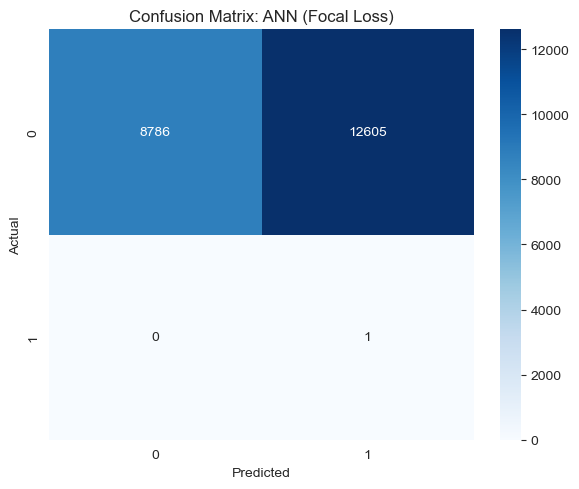

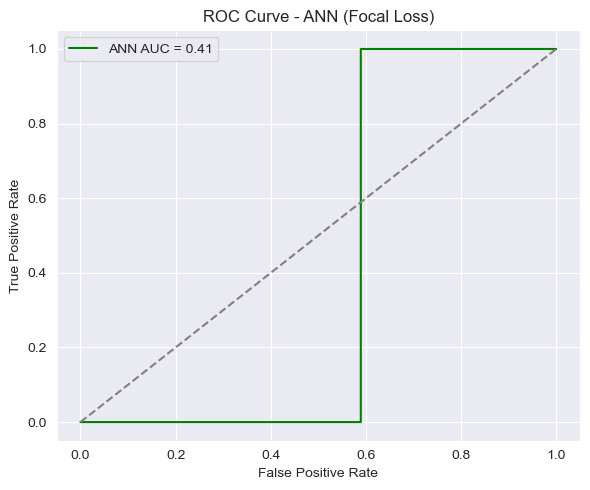

In [25]:
# Define the ANN model
def create_complex_ann():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train_resampled.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    focal_loss = BinaryFocalCrossentropy(gamma=2.0)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=focal_loss, metrics=['Recall'])
    return model

# Wrap in KerasClassifier for calibration
keras_clf = KerasClassifier(model=create_complex_ann, epochs=15, batch_size=32, verbose=2)
keras_clf.fit(X_train_resampled, y_train_resampled)

# Evaluating the Model
# Predict probabilities
y_proba_ann = keras_clf.predict_proba(X_test_df)[:, 1]

# Threshold Optimization
precision_ann, recall_ann, thresholds_ann = precision_recall_curve(y_test, y_proba_ann)
f2_scores_ann = 5 * (precision_ann * recall_ann) / (4 * precision_ann + recall_ann + 1e-6)
optimal_threshold_ann = thresholds_ann[np.argmax(f2_scores_ann)]
print(f"\nOptimal Threshold (ANN): {optimal_threshold_ann:.4f}")

# Apply threshold
y_pred_ann_opt = (y_proba_ann >= optimal_threshold_ann).astype(int)

# Metrics
print("\nClassification Report (ANN):")
print(classification_report(y_test, y_pred_ann_opt))

roc_auc_ann = roc_auc_score(y_test, y_proba_ann)
print(f"ROC-AUC Score (ANN): {roc_auc_ann:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ann_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: ANN (Focal Loss)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_proba_ann)
plt.figure(figsize=(6, 5))
plt.plot(fpr_ann, tpr_ann, label=f"ANN AUC = {roc_auc_ann:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN (Focal Loss)")
plt.legend()
plt.tight_layout()
plt.show()

#### MODEL COMPARISON

Model Performance Comparison:
                 Model   ROC-AUC  Optimal_Threshold
0  Logistic Regression  0.997709           0.594425
1        Random Forest  0.986162           0.306859
2                  ANN  0.410733           0.000314


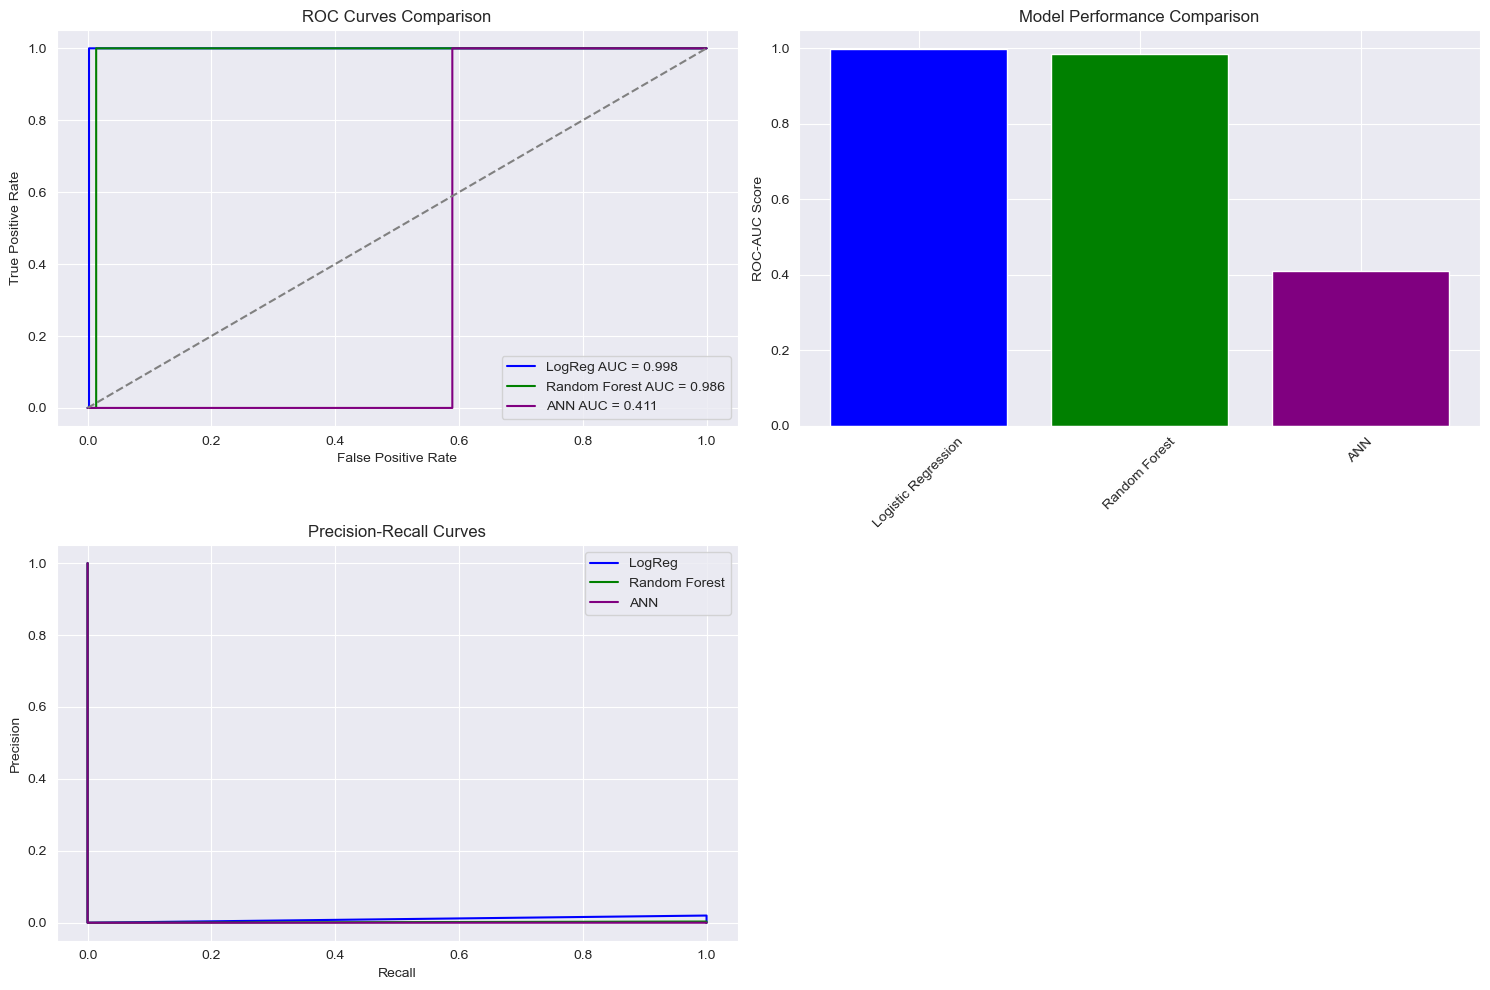

In [27]:
# Create comparison dataframe
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'ANN'],
    'ROC-AUC': [roc_auc, roc_auc_rf, roc_auc_ann],
    'Optimal_Threshold': [optimal_threshold_logreg, optimal_threshold_rf,
                          optimal_threshold_ann]
})

print("Model Performance Comparison:")
print(models_comparison)

# Plot comparison
plt.figure(figsize=(15, 10))

# ROC Curves Comparison
plt.subplot(2, 2, 1)
plt.plot(fpr, tpr, label=f"LogReg AUC = {roc_auc:.3f}", color='blue')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.3f}", color='green')
plt.plot(fpr_ann, tpr_ann, label=f"ANN AUC = {roc_auc_ann:.3f}", color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()

# AUC Scores Bar Plot
plt.subplot(2, 2, 2)
plt.bar(models_comparison['Model'], models_comparison['ROC-AUC'],
        color=['blue', 'green', 'purple'])
plt.ylabel('ROC-AUC Score')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)

# Precision-Recall Curves
plt.subplot(2, 2, 3)
plt.plot(recall, precision, label=f"LogReg", color='blue')
plt.plot(recall_rf, precision_rf, label=f"Random Forest", color='green')
plt.plot(recall_ann, precision_ann, label=f"ANN", color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()

plt.tight_layout()
plt.show()

#### BUSINESS INSIGHTS AND RECOMMENDATIONS

In [28]:
print("1. CUSTOMER SEGMENTATION INSIGHTS:")
print("   - Identified", optimal_k, "distinct customer segments with different cancellation behaviors")
print("   - Statistical tests show significant differences in cancellation rates across segments")
if p_value < 0.05:
    print("   - Clusters show statistically significant differences in cancellation behavior (p < 0.05)")
else:
    print("   - No statistically significant differences found between clusters")

if p_value_ttest < 0.05:
    print("   - First-time vs repeat buyers show significantly different cancellation rates (p < 0.05)")
else:
    print("   - No significant difference between first-time and repeat buyers")

print("\n2. PREDICTIVE MODEL PERFORMANCE:")
best_model_idx = models_comparison['ROC-AUC'].idxmax()
best_model = models_comparison.loc[best_model_idx, 'Model']
best_auc = models_comparison.loc[best_model_idx, 'ROC-AUC']
print(f"   - Best performing model: {best_model} (AUC = {best_auc:.3f})")

print("\n3. KEY RISK FACTORS FOR CANCELLATION:")
print("   - Top features from Random Forest analysis:")
for i, row in feature_importance.head(5).iterrows():
    print(f"     • {row['feature']}: {row['importance']:.3f}")

print("\n4. ACTIONABLE RECOMMENDATIONS:")
print("   a) CUSTOMER SEGMENTATION STRATEGY:")
print("      - Develop targeted retention programs for high-risk customer segments")
print("      - Customize communication and offers based on cluster characteristics")
print("      - Monitor cluster-specific cancellation rates as KPIs")

print("   b) EARLY WARNING SYSTEM:")
print(f"      - Implement {best_model} model for real-time churn prediction")
print("      - Set up automated alerts when cancellation probability exceeds threshold")
print("      - Focus on customers with high handoff delays and shipping distances")

print("   c) OPERATIONAL IMPROVEMENTS:")
print("      - Reduce handoff delays (key predictor of cancellations)")
print("      - Optimize shipping for long-distance orders")
print("      - Improve review management to maintain high satisfaction scores")

print("   d) FIRST-TIME BUYER STRATEGY:")
if abs(first_time_cancel.mean() - repeat_cancel.mean()) > 0.05:
    if first_time_cancel.mean() > repeat_cancel.mean():
        print("      - First-time buyers show higher cancellation rates")
        print("      - Implement welcome programs and enhanced support for new customers")
        print("      - Provide clearer delivery expectations and tracking information")
    else:
        print("      - Repeat buyers show higher cancellation rates")
        print("      - Focus on loyalty programs and relationship management")
        print("      - Investigate why experienced customers are canceling more")
else:
    print("      - Similar cancellation rates between buyer types")
    print("      - Apply uniform retention strategies across all customer types")

print("\n5. MONITORING AND CONTINUOUS IMPROVEMENT:")
print("   - Retrain models monthly with new data")
print("   - Track model performance metrics and recalibrate thresholds")
print("   - A/B test interventions based on model predictions")
print("   - Expand feature set to include browsing patterns and session data")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

# Save results summary
results_summary = {
    'segmentation_clusters': optimal_k,
    'best_model': best_model,
    'best_auc': best_auc,
    'cluster_anova_pvalue': p_value,
    'buyer_type_ttest_pvalue': p_value_ttest,
    'top_features': feature_importance.head(5).to_dict('records')
}

print("\nResults Summary:")
for key, value in results_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nThis analysis provides a comprehensive framework for:")
print("- Understanding customer segments and their cancellation behaviors")
print("- Predicting cancellation risk using multiple ML approaches")
print("- Implementing data-driven retention strategies")
print("- Reducing churn through targeted interventions")

1. CUSTOMER SEGMENTATION INSIGHTS:
   - Identified 4 distinct customer segments with different cancellation behaviors
   - Statistical tests show significant differences in cancellation rates across segments
   - Clusters show statistically significant differences in cancellation behavior (p < 0.05)
   - First-time vs repeat buyers show significantly different cancellation rates (p < 0.05)

2. PREDICTIVE MODEL PERFORMANCE:
   - Best performing model: Logistic Regression (AUC = 0.998)

3. KEY RISK FACTORS FOR CANCELLATION:
   - Top features from Random Forest analysis:
     • handoff_delay: 0.075
     • seller_id_620c87c171fb2a6dd6e8bb4dec959fc6: 0.057
     • seller_state_sp: 0.052
     • seller_city_petropolis: 0.051
     • product_width_cm: 0.050

4. ACTIONABLE RECOMMENDATIONS:
   a) CUSTOMER SEGMENTATION STRATEGY:
      - Develop targeted retention programs for high-risk customer segments
      - Customize communication and offers based on cluster characteristics
      - Monitor clus